# GSE202642: PGAM5 and immune RNA programs within the original 15 groups
All program scores retain PGAM5. This executed companion checks portable inputs, reproduces scoring and observed correlations, independently checks BH adjustment, and displays the permutation results. Run `python analyze.py` to rerun all 9,999 permutations; `python plot_report.py` regenerates the figures and report. These are exploratory RNA associations, not causal immune function tests.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd
from scipy.stats import spearmanr
from IPython.display import display, Image
R=Path.cwd()
a=pd.read_csv(R/'cell_metadata.csv.gz',index_col=0)
genes=pd.read_csv(R/'program_genes.csv').gene.tolist()
raw=np.load(R/'program_raw_counts.npz')['counts']
panels=json.loads((R/'program_definitions.json').read_text())
assert all(gs.count('PGAM5')==1 for gs in panels.values())
assert np.array_equal(raw[:,genes.index('PGAM5')],a.PGAM5_counts)
assert len(a)==12135 and int((a.PGAM5_counts>0).sum())==868
z=np.log1p(raw/a.total_counts.to_numpy()[:,None]*10000)
x=z[:,genes.index('PGAM5')]
scores=pd.DataFrame({p:z[:,[genes.index(g) for g in gs]].mean(axis=1) for p,gs in panels.items()},index=a.index)
stored=pd.read_csv(R/'cell_program_scores.csv.gz',index_col=0)
assert np.allclose(scores,stored)
display(pd.DataFrame({'program':list(panels),'genes_including_PGAM5':[len(gs) for gs in panels.values()]}))

,program,genes_including_PGAM5
0,IFN_gamma_response,8
1,T_cell_recruitment,5
2,Type1_effector_support,6
3,MHC_II_presentation,10
4,MHC_I_processing,10
5,Inhibitory_signaling_RNA,8
6,Lipid_associated_TAM,10
7,Matrix_remodeling,9
8,Inflammatory_NFkB,9
9,Neutrophil_recruitment,6


## Self-inclusion-preserving null
For each subgroup, permute PGAM5 X, rebuild S=(permuted X + unchanged other member sum)/m, and correlate permuted X with S. This preserves the mechanical shared-gene term. Report observed rho, null median, delta rho, two-sided equal-tail permutation p, and BH q across all 168 valid tests. C1 has no PGAM5 variation; C10 uses exact enumeration of its single detected cell. Null envelopes are not confidence intervals.

In [2]:
results=pd.read_csv(R/'subgroup_program_associations.csv')
for row in results.itertuples():
    ix=np.flatnonzero(a.primary_cluster.to_numpy()==row.cluster)
    if (x[ix]>0).any():
        assert np.isclose(spearmanr(x[ix],scores[row.program].to_numpy()[ix]).statistic,row.rho)
    else:
        assert pd.isna(row.rho) and pd.isna(row.p_calibrated)
valid=results.p_calibrated.notna()
p=results.loc[valid,'p_calibrated'].to_numpy(); order=np.argsort(p)
sorted_q=np.minimum.accumulate((p[order]*len(p)/np.arange(1,len(p)+1))[::-1])[::-1]
q=np.empty(len(p));q[order]=np.minimum(1,sorted_q)
assert np.allclose(q,results.loc[valid,'q_BH'])
assert valid.sum()==168 and len(results)==180
assert np.allclose(results.loc[valid,'delta_rho'],results.loc[valid,'rho']-results.loc[valid,'null_median'])
display(results.loc[(results.q_BH<.05)&(~results.mixed_RNA_flag)&(~results.low_information),['cluster','program','rho','null_median','delta_rho','p_calibrated','q_BH']].sort_values('q_BH').head(20))
print('Input, scoring, 168 observed correlations, BH and delta checks passed.')

,cluster,program,rho,null_median,delta_rho,p_calibrated,q_BH
91,7,Matrix_remodeling,0.318965,0.072690,0.246275,0.0002,0.005600
84,7,IFN_gamma_response,0.352160,0.128965,0.223195,0.0002,0.005600
93,7,Neutrophil_recruitment,0.430147,0.288961,0.141186,0.0002,0.005600
92,7,Inflammatory_NFkB,0.275475,0.075625,0.199850,0.0002,0.005600
138,11,Lipid_associated_TAM,0.209093,0.047411,0.161682,0.0002,0.005600
94,7,Oxidative_stress_response,0.297547,0.125548,0.171998,0.0004,0.008400
55,4,Matrix_remodeling,0.187336,0.031855,0.155481,0.0004,0.008400
38,3,Type1_effector_support,0.218555,0.149462,0.069094,0.0006,0.011200
139,11,Matrix_remodeling,0.227183,0.091998,0.135185,0.0012,0.016800
88,7,MHC_I_processing,0.246464,0.089769,0.156695,0.0012,0.016800


Input, scoring, 168 observed correlations, BH and delta checks passed.


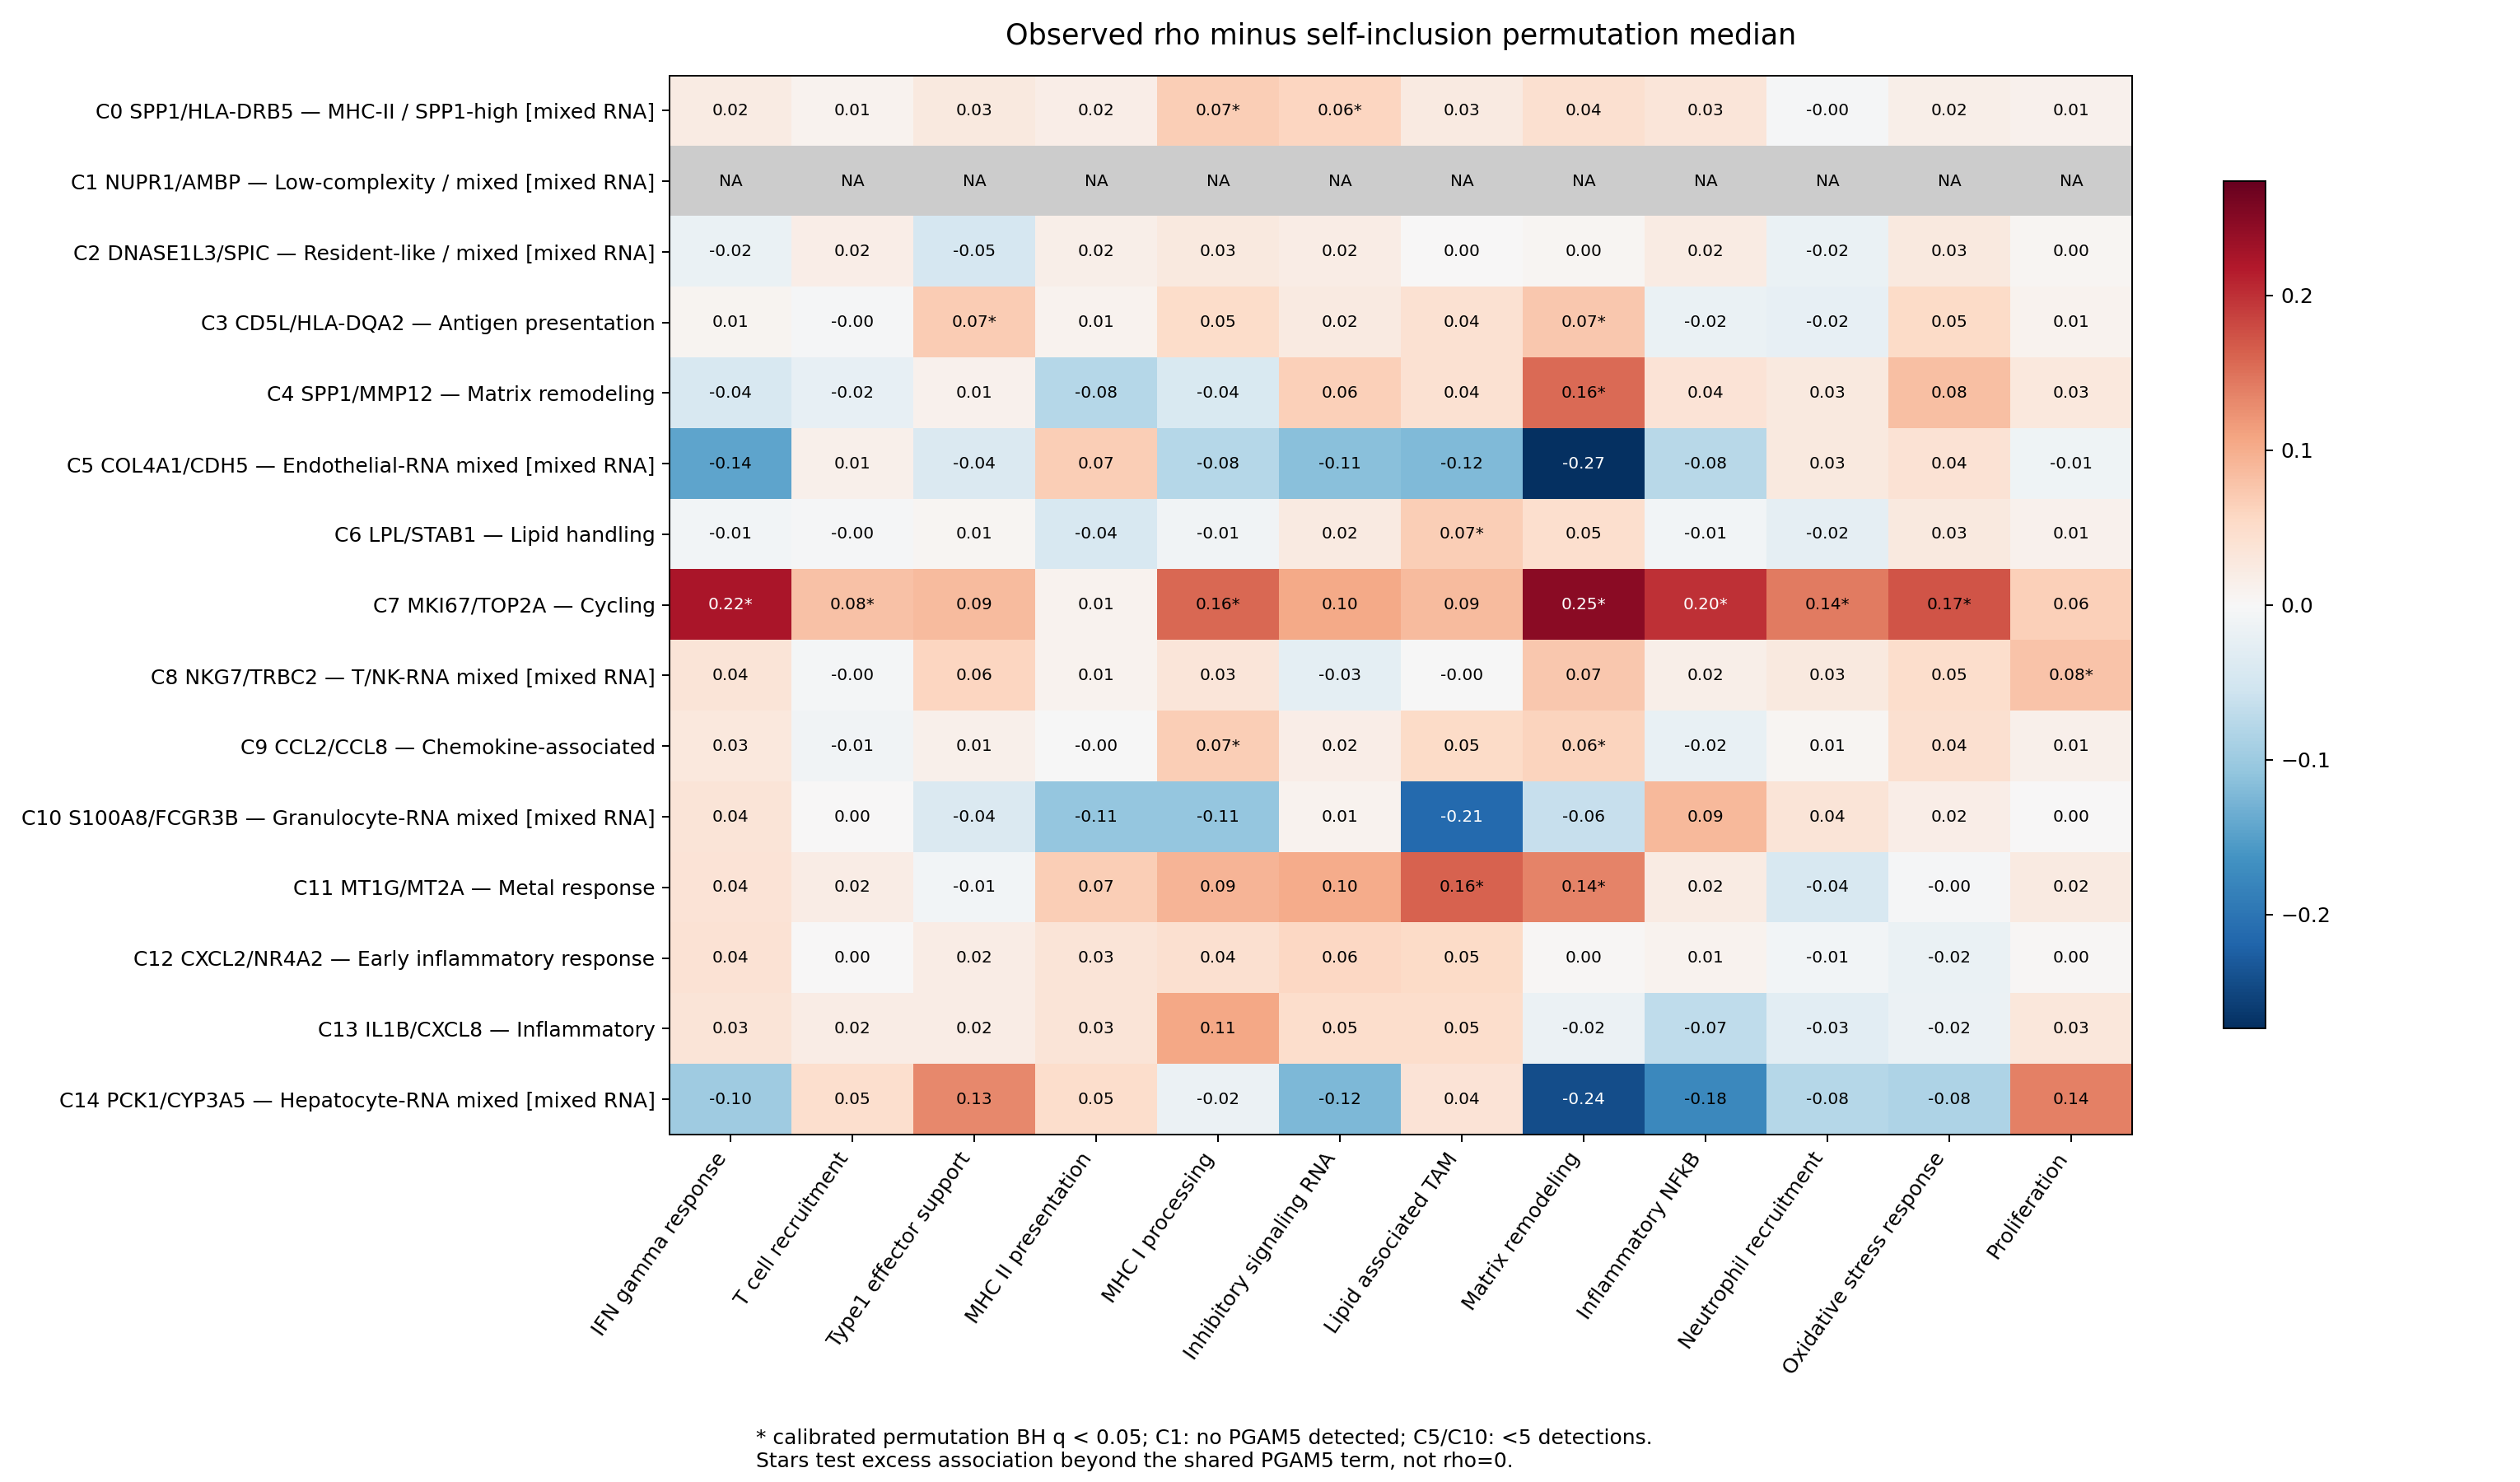

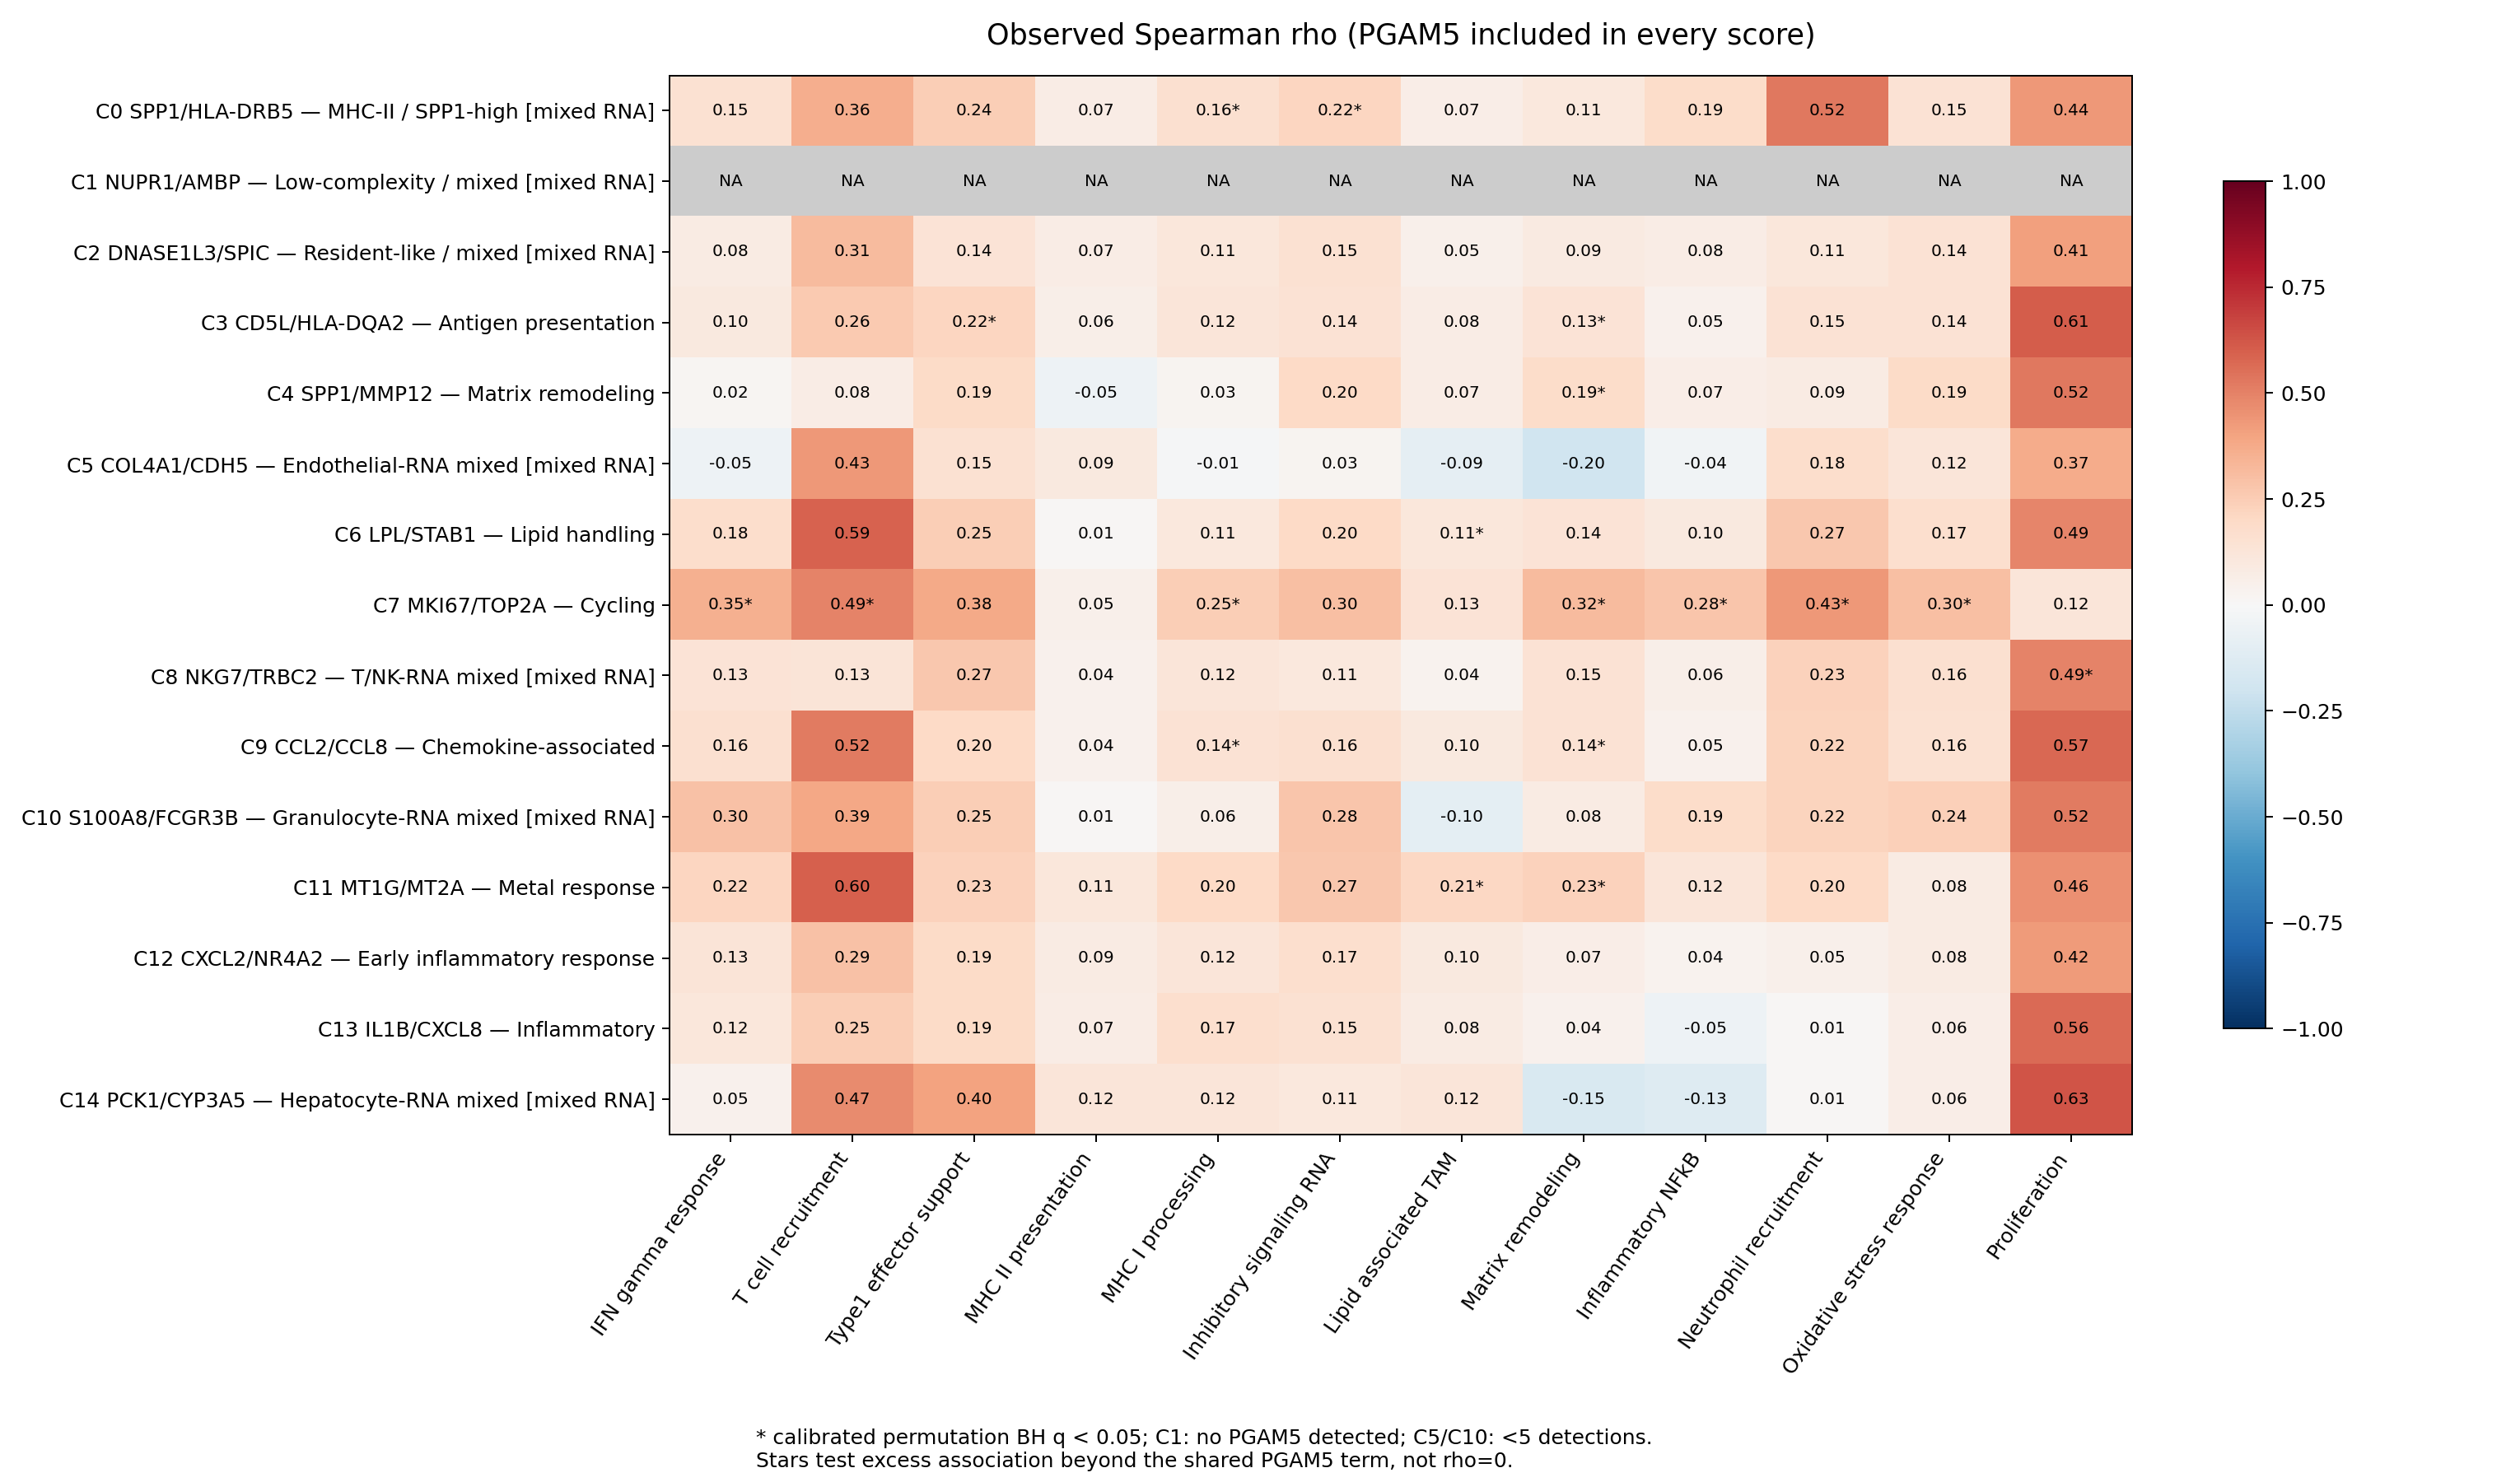

In [3]:
display(Image(filename=str(R/'self_inclusion_calibrated_associations.png')))
display(Image(filename=str(R/'observed_correlations.png')))

## Interpretation
Positive raw correlations can arise from including PGAM5 in the outcome. Interpret calibrated excess associations, with RNA program overlap, cell dependence, sparse detections, mixed RNA groups, and highly uneven patient composition in mind. Patient direction diagnostics are descriptive and subtract only the known shared-term covariance from the full score; they are not patient-level significance tests. No library-depth matching/regression was performed. No conclusion of enhanced or reduced antitumor immunity is established.